# **Malaria Detection**

##<b>Problem Definition</b>
**The context:** Why is this problem important to solve?<br>


*   Malaria is a contagious disease that is lethal and could impact 50% of the world's population. The ability to automate the detection of Malaria would allow for early intervention to treat infected patients much quicker, and therefore save lives.


**The objectives:** What is the intended goal?<br>


*   Accurately discriminate between healthy and infected red blood cells using the data set provided, and build a model that is trained on such data set to use existing knowledge to predict and assess whether a new patient's red blood cells are infected or not. Further, providing a tool for healthcare providers to use to assess whether a patient has Malaria or not.


**The key questions:** What are the key questions that need to be answered?<br>

*   Can the finalized model articulate with high accuracy whether a cell is infected or uninfected?

*   Will the finalized model be trusted among healthcare providers to assist in making accurate assessments of a patients current state?


**The problem formulation:** What is it that we are trying to solve using data science?


*   We are providing a tool that healthcare providers can use to assist in diagnosing whether a patient has Malaria much quicker in comparison to traditional methods, to further provide earlier intervention in treating the patient impacted.



## <b>Data Description </b>

There are a total of 24,958 train and 2,600 test images (colored) that we have taken from microscopic images. These images are of the following categories:<br>

**Parasitized:** The parasitized cells contain the Plasmodium parasite which causes malaria<br>
**Uninfected:** The uninfected cells are free of the Plasmodium parasites<br>

## <b>Data patterns </b>
Some key patterns that are recognized are the ring-like structures that appear in the parasitized cells. This is a key distinguisher between infected versus uninfected in which the model can learn from. The parasitized cells ring-like structures appear to be in different locations within the cell and appear to be darker.

## <b>Data treatments </b>
The data treatments or pre-processing required are to condense the image size and process images in batches for daster processing and efficient use of memory resource.


###<b> Mount the Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### <b>Loading libraries</b>

In [ ]:
# Library for creating data paths
import os

# Library for randomly selecting data points
import random

# Library for performing numerical computations
import numpy as np

# Library for creating and showing plots
import matplotlib.pyplot as plt

# Library for reading and showing images
import matplotlib.image as mpimg

# Importing all the required sub-modules from Keras
from keras.models import Sequential, Model
from keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import img_to_array, load_img
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, LeakyReLU
import pandas as pd
import seaborn as sns

### <b>Let us load the data</b>

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same to your Google Drive. Then unzip the folder.

The extracted folder has different folders for train and test data will contain the different sizes of images for parasitized and uninfected cells within the respective folder name.

The size of all images must be the same and should be converted to 4D arrays so that they can be used as an input for the convolutional neural network. Also, we need to create the labels for both types of images to be able to train and test the model.

Let's do the same for the training data first and then we will use the same code for the test data as well.

In [ ]:
#Create a main directory, train, and test directories for Malaria and Non-Malaria cases.

#First access point where all images are stored via Google Drive - main directory
main_drt = '/content/drive/MyDrive/MIT - Capstone Project/cell_images'

#Second access point into images for training are stored - train directory
train_drt = os.path.join(main_drt, 'train')
#Second access point into images for tests are stored - test directory
test_drt = os.path.join(main_drt, 'test')
#Third access point into images to train where: Malaria
train_m_drt = os.path.join(train_drt, 'parasitized')
#Third access point into images to train where: No Malaria
train_no_drt = os.path.join(train_drt, 'uninfected')
#Third access point into images to test where: Malaria
test_m_drt = os.path.join(test_drt, 'parasitized')
#Third access point into images to test where: No Malaria
test_no_drt = os.path.join(test_drt, 'uninfected')

print(f"Main directory: {main_drt}")
print(f"Train directory: {train_drt}")
print(f"Test directory: {test_drt}")

Main directory: /content/drive/MyDrive/MIT - Capstone Project/cell_images
Train directory: /content/drive/MyDrive/MIT - Capstone Project/cell_images/train
Test directory: /content/drive/MyDrive/MIT - Capstone Project/cell_images/test


In [ ]:
#create parameters for ImageDataGenerator to adjust image dimensions to reduce computational load and memory usage making training faster and more feasible

#image dimensions
img_h = 64
img_w = 64
channel = 3 #for RGB images

#batch size
batch_size = 64

### <b>Normalize the Images</b>

In [ ]:
#ImageDataGenerator from Keras will load images from directories, apply resizing, and prepare in batches as 4D arrays.

#ImageDataGenerator for training data, rescale for normalization
train_datagen = ImageDataGenerator(rescale=1./255)

#ImageDataGenerator for test data, rescale for normalization
test_datagen = ImageDataGenerator(rescale=1./255)

#generate batches of augmented data for training
train_generator = train_datagen.flow_from_directory(
    train_drt,
    target_size=(img_h, img_w),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

#generate batches of augmented data for testing
test_generator = test_datagen.flow_from_directory(
    test_drt,
    target_size=(img_h, img_w),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 24954 images belonging to 2 classes.
Found 2600 images belonging to 2 classes.


###<b> Check the shape of train and test labels

In [ ]:
#retrieve batch of training images and labels
train_batch_images, train_batch_labels = next(train_generator)

#print shape of the images and labels
print(f"Shape of one batch of training images: {train_batch_images.shape}")
print(f"Shape of one batch of training labels: {train_batch_labels.shape}")

#retrieve a batch of test images and labels
test_batch_images, test_batch_labels = next(test_generator)

#print shape of the images and labels
print(f"Shape of one batch of test images: {test_batch_images.shape}")
print(f"Shape of one batch of test labels: {test_batch_labels.shape}")

#print class indices mapping
print("Class indices:", train_generator.class_indices)

Shape of one batch of training images: (64, 64, 64, 3)
Shape of one batch of training labels: (64,)
Shape of one batch of test images: (64, 64, 64, 3)
Shape of one batch of test labels: (64,)
Class indices: {'parasitized': 0, 'uninfected': 1}


###<b> Check the shape of train and test images

In [ ]:
#check shape of train images
print(train_batch_images.shape)
#check shape of test images
print(test_batch_images.shape)

(64, 64, 64, 3)
(64, 64, 64, 3)


####<b> Observations and insights:

In the train set:

*   The first dimension 32 denotes the number of images in the training data, and each image is stacked on top of the other as a 3-dimensional Numpy array.
*  The second dimension 64 denotes the number of pixels along the X-axis, the third dimension 64 denotes the number of pixels along the Y-axis, and the fourth dimension 3 is the total number of channels in those images.

These are the red, green, and blue channels.

In the test set:  

*   The first dimension 32 denotes the number of images in the training data, and each image is stacked on top of the other as a 3-dimensional Numpy array.
*   The second dimension 64 denotes the number of pixels along the X-axis, the third dimension 64 denotes the number of pixels along the Y-axis, and the fourth dimension 3 is the total number of channels in those images.

These are the red, green, and blue channels.

The test and train set shapes are identical.

### <b>Check the minimum and maximum range of pixel values for train and test images

In [ ]:
#min pix value for training images
print(f"Minimum number of pixel values for the training set is: {np.round(train_batch_images.min(),2)}")
#max pix value for training images
print(f"Maximum number of pixel values for the training set is:", np.round(train_batch_images.max(),2))
#min pix value for test images
print(f"Minimum number of pixel values for the test set is: {test_batch_images.min()}")
#max pix value for test images
print(f"Maximum number of pixel values for the training set is:", np.round(test_batch_images.max(),2))

Minimum number of pixel values for the training set is: 0.0
Maximum number of pixel values for the training set is: 0.94
Minimum number of pixel values for the test set is: 0.0
Maximum number of pixel values for the training set is: 0.89


####<b> Observations and insights:


* The minimum and maximum pixel values stay within range 0 to 1, further validating that the images are normalized. Normalization is important to ensure faster training, prevent activation function saturation aka vanishing gradients, and improve model generalization by making it less sensitive to lighting/contrast variations, leading to more stable learning and better performance





###<b> Count the number of values in both uninfected and parasitized

In [ ]:
#count images in train_m_drt (parasitized)
num_train_parasitized = len(os.listdir(train_m_drt))
print(f"Number of parasitized images in training set: {num_train_parasitized}")

#count images in train_no_drt (uninfected)
num_train_uninfected = len(os.listdir(train_no_drt))
print(f"Number of uninfected images in training set: {num_train_uninfected}")

#count images in test_m_drt (parasitized)
num_test_parasitized = len(os.listdir(test_m_drt))
print(f"Number of parasitized images in test set: {num_test_parasitized}")

#count images in test_no_drt (uninfected)
num_test_uninfected = len(os.listdir(test_no_drt))
print(f"Number of uninfected images in test set: {num_test_uninfected}")

Number of parasitized images in training set: 12582
Number of uninfected images in training set: 12372
Number of parasitized images in test set: 1300
Number of uninfected images in test set: 1300


####<b> Observations and insights:


*   The number of parasitized images in the training set is 12,582 and the number in uninfected images in the training set is 12,372.
There is a slight deviation in # of images around

*   There is a slight difference of 210 between parasitized and uninfected images. However, this is a small difference in contrast to the number of images provided, hence, this should not be a worry.

*  The number of parasitized images and uninfected images in the test sets are equal at 1300.

*   Overall, it is normal for the training set to have more data than the test set, as the model needs ample examples to learn patterns.



In [ ]:
#empty lists to store all images and labels from the generator
all_train_images = []
all_train_labels = []

#iterate over the train_generator to collect all images and labels
#num of steps is = total number of images / batch size
num_batches_to_process = 100 #process 100 batches to reduce data size for faster execution
for i in range(num_batches_to_process):
    images_batch, labels_batch = next(train_generator)
    all_train_images.extend(images_batch)
    all_train_labels.extend(labels_batch)

#convert lists to numpy arrays
train_images = np.array(all_train_images)
train_labels = np.array(all_train_labels)
print(f"Shape of train_labels after generator collection: {train_labels.shape}")

Shape of train_labels after generator collection: (6400,)


In [ ]:
#empty lists to store all images and labels from the test generator
all_test_images = []
all_test_labels = []

#iterate the test_generator to collect all images and labels
#num batches = 100 for resource constraints (memory)
num_batches_to_process = 100
for i in range(num_batches_to_process):
    images_batch, labels_batch = next(test_generator)
    all_test_images.extend(images_batch)
    all_test_labels.extend(labels_batch)

#convert lists to numpy arrays
test_images = np.array(all_test_images)
test_labels = np.array(all_test_labels)
print(f"Shape of test_labels after generator collection: {test_labels.shape}")

Shape of test_labels after generator collection: (6352,)


###<b> Plot to check if the data is balanced

In [ ]:
#create function to plot data to check if it is in balance
def plot_images(images, labels, class_indices, rows=3, cols=4, figsize=(10, 8)):
    #invert class_indices to get label names from numerical labels
    label_map = {v: k for k, v in class_indices.items()}

    # Separate images and labels by class
    parasitized_images = [img for img, label in zip(images, labels) if label_map[label] == 'parasitized']
    uninfected_images = [img for img, label in zip(images, labels) if label_map[label] == 'uninfected']

    display_images = []
    display_labels = []

    # Determine how many from each class to plot to keep it balanced, up to rows*cols total
    num_to_plot_per_class = (rows * cols) // 2

    # Randomly select images from each class
    if len(parasitized_images) > 0:
        indices = np.random.choice(len(parasitized_images), min(len(parasitized_images), num_to_plot_per_class), replace=False)
        for i in indices:
            display_images.append(parasitized_images[i])
            display_labels.append('parasitized')

    if len(uninfected_images) > 0:
        indices = np.random.choice(len(uninfected_images), min(len(uninfected_images), num_to_plot_per_class), replace=False)
        for i in indices:
            display_images.append(uninfected_images[i])
            display_labels.append('uninfected')

    # Shuffle the combined list to mix parasitized and uninfected images
    combined = list(zip(display_images, display_labels))
    random.shuffle(combined)
    display_images, display_labels = zip(*combined)

    fig = plt.figure(figsize=figsize)
    for n in range(min(rows * cols, len(display_images))): # Ensure we don't try to plot more than we have
        ax = fig.add_subplot(rows, cols, n + 1)
        ax.imshow(display_images[n])
        ax.set_title(display_labels[n])
        ax.axis('off')
    plt.tight_layout() #adjust subplot params for a tight layout
    plt.show()

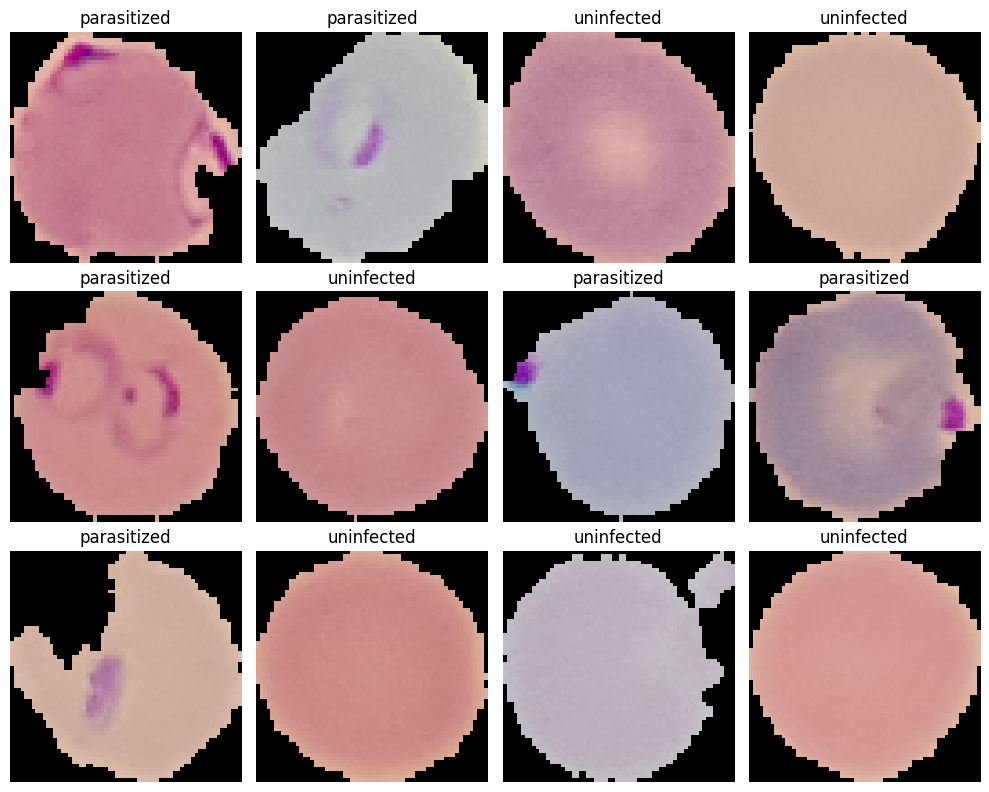

In [ ]:
plot_images(train_batch_images, train_batch_labels, train_generator.class_indices)

####<b> Observations and insights:


*   There are exactly 6 parasitized images and 6 uninfected images. The data is perfectly balanced.



### <b>Data Exploration</b>
Let's visualize the images from the train data

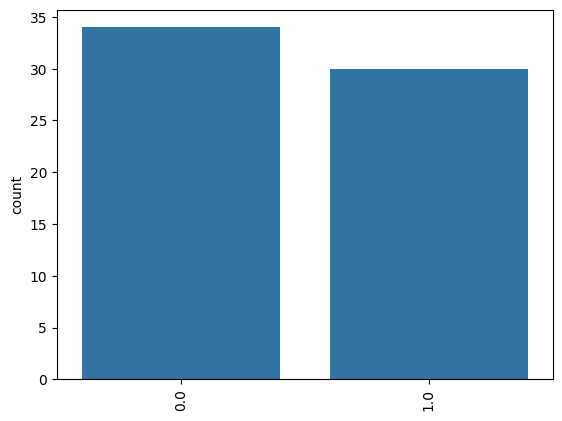

In [ ]:
sns.countplot(x=train_batch_labels);
plt.xticks(rotation = 'vertical');

####<b> Observations and insights:


*   In a single batch, there appears to be ~16 uninfected images and ~16 parasitized images in the training set.



###<b> Visualize the images with subplot(6, 6) and figsize = (12, 12)

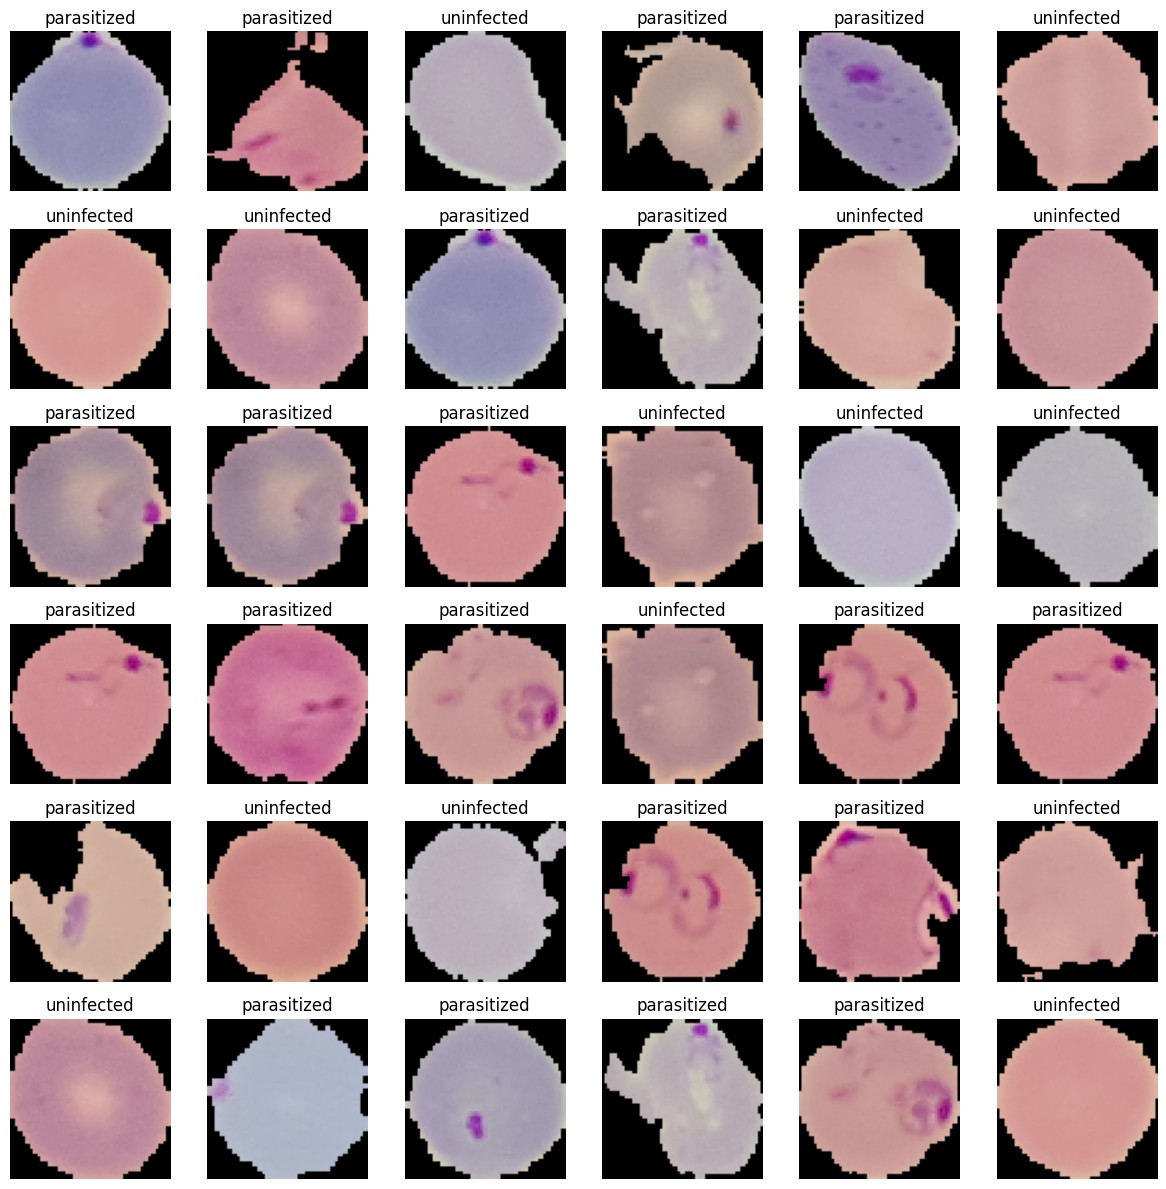

In [ ]:
#visualizing both the parasitized and uninfected images
np.random.seed(42)

plt.figure(1, figsize = (12 , 12))

#class mapping from the generator
class_labels = {v: k for k, v in train_generator.class_indices.items()}

for n in range(1, 37):
    plt.subplot(6, 6, n)

    #gen random index within the current batch of images
    index = np.random.randint(0, len(train_batch_images)) #removed the size=1 argument

    #display the image
    plt.imshow(train_batch_images[index])

    #set title based on the label
    label_value = train_batch_labels[index]
    plt.title(class_labels[int(label_value)]) #map numerical label to string

    plt.axis('off')

plt.tight_layout() #adjust subplot params for a tight layout
plt.show()

####<b>Observations and insights:


*   There are 18 uninfected images and 18 parasitized images randomly pulled from the training data set.



*   The uninfected cell image appears smooth. The parasitized cell image often shows a distinct darker or more textured region within the cell. I believe the darker area represents the presence of the malaria parasite, which can vary in shape and size depending on its developmental stage, but often presents as a visible mass or ring-like structure when averaged across many infected cells.



*   It appears labeling in somewhat correct, with some slight errors made in mis-labeling a parasitized for an uninfected cell. As shown in the first row, 4th image across. The cell appears that it may be at the early stages of infection or recovery stages. A human would have to take a closer look at this to validate further.





###<b> Plotting the mean images for parasitized and uninfected

In [ ]:
#create function to find the mean
def find_mean_img(full_mat, title):

    #calc the average
    mean_img = np.mean(full_mat, axis = 0)[0]

    #reshape back to a matrix
    plt.imshow(mean_img)

    plt.title(f'Average {title}')

    plt.axis('off')

    plt.show()

    return mean_img

<b> Mean image for parasitized

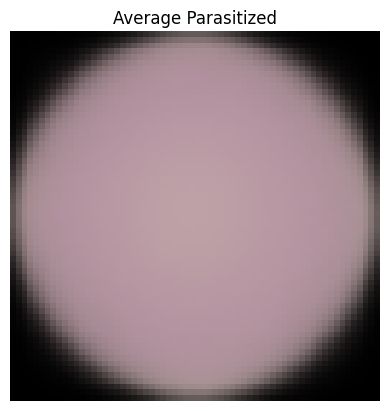

In [ ]:
# If the label = 1 then the image is parasitised and if the label = 0 then the image is uninfected
parasitized_data = []  # Create a list to store the parasitized data
for img, label in zip(train_images, train_labels):
        if label == 1:
              parasitized_data.append([img])
parasitized_mean = find_mean_img(np.array(parasitized_data), 'Parasitized')   # find the mean

<b> Mean image for uninfected

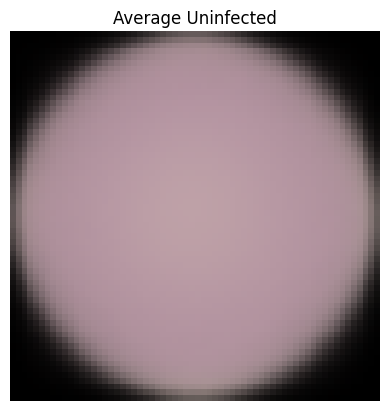

In [ ]:
# If the label = 1 then the image is parasitised and if the label = 0 then the image is uninfected
uninfected_data = []  # Create a list to store the parasitized data
for img, label in zip(train_images, train_labels):
        if label == 1:
              uninfected_data.append([img])
uninfected_mean = find_mean_img(np.array(uninfected_data), 'Uninfected')   # find the mean

####<b> Observations and insights:


*   It appears the uninfected and parasitized mean image look identical. Perhaps the reason is due to the varying nature of the ring-like structure that is found in infected cells.



### <b>Converting RGB to HSV of Images using OpenCV

###<b> Converting the train data

In [ ]:
import cv2

gfx=[]

#convert images to 0-255 and convert to uint8 for OpenCV, then convert to HSV
#limit to first 100 images for demonstration to avoid excessive memory usage
for i in np.arange(0, min(100, len(train_images)), 1):
  #ensure image is in the 0-255 range and uint8 type for OpenCV
  img_255 = (train_images[i] * 255).astype(np.uint8)
  a = cv2.cvtColor(img_255, cv2.COLOR_RGB2HSV)
  gfx.append(a)

gfx = np.array(gfx)

###<b> Converting the test data

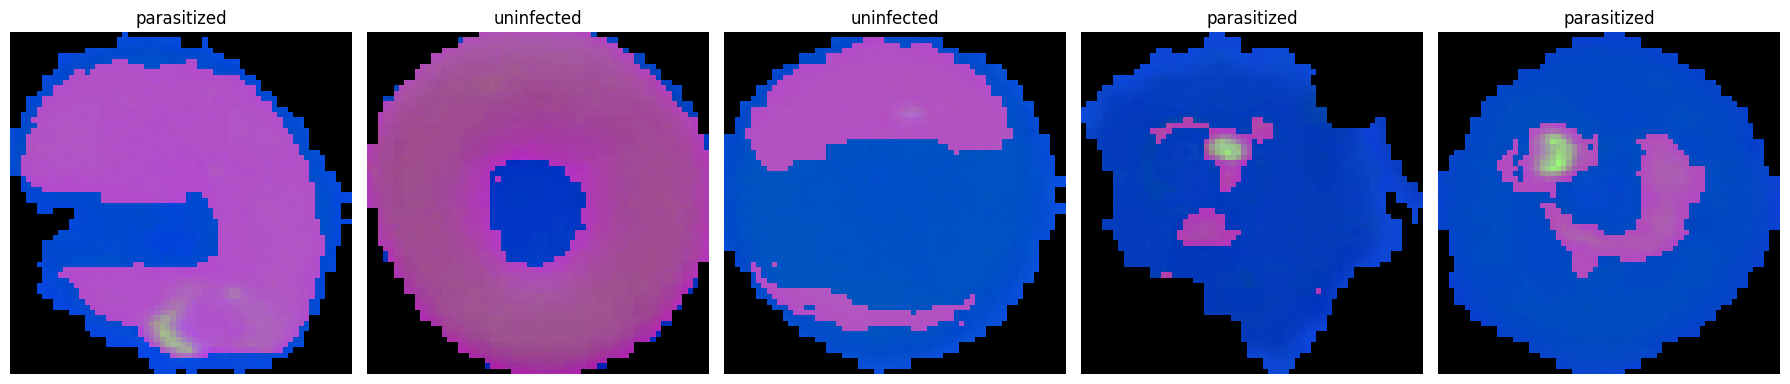

In [ ]:
#get class mapping from the generator for titles
class_labels_map = {v: k for k, v in train_generator.class_indices.items()}

viewimage = np.random.randint(0, len(gfx), 5) #select random indices from the converted images

fig, ax = plt.subplots(1, 5, figsize = (18, 18))
for t, i in zip(range(5), viewimage):
  #use original label (from the first 100 training labels) to get the class name
  original_label_index = np.arange(0, min(100, len(train_images)), 1)[i] # Get index within the first 100 images
  Title = class_labels_map[int(train_labels[original_label_index])]

  ax[t].set_title(Title)

  #display the HSV image (matplotlib can display HSV as RGB if it's 0-1 or 0-255)
  ax[t].imshow(gfx[i])

  ax[t].set_axis_off()

fig.tight_layout()

####<b>Observations and insights:


*   Converting the images from RGB to HSV, highlights the visible mass or ring-like structure of a infected cell far more than what we have seen thus far. The highlight could allow for quicker decision-making when assessing whether a patient is infected or not.



###<b> Processing Images using Gaussian Blurring

####**Observations and insights: **

**Think About It:** Would blurring help us for this problem statement in any way? What else can we try?

Gaussian Blurring could assist in the following:


*   Noise reduction: typically, microscopic images often have a lot of noise (ex: speckles, uneven illumination, etc), Gaussian Blur can smooth out these imperfections, therefore allowing the model to focus on the ring-like structures within the cells rather than the imperfections.
*   Generalization: smoothing the image can help the model generalize better. Noise varies in the images provided, so reducing them can help make the features - aka the ring-liek structure - more prominent.






###<b> Gaussian Blurring on train data

In [ ]:
gbx = []  # To hold the blurred images

# Scale images to 0-255 and convert to uint8 for OpenCV, then apply Gaussian Blur
# Limiting to first 100 images for demonstration to avoid excessive memory usage
for i in np.arange(0, min(100, len(train_images)), 1):
  # Ensure the image is in the 0-255 range and uint8 type for OpenCV
  img_255 = (train_images[i] * 255).astype(np.uint8)
  b = cv2.GaussianBlur(img_255, (5, 5), 0)
  gbx.append(b)

gbx = np.array(gbx)

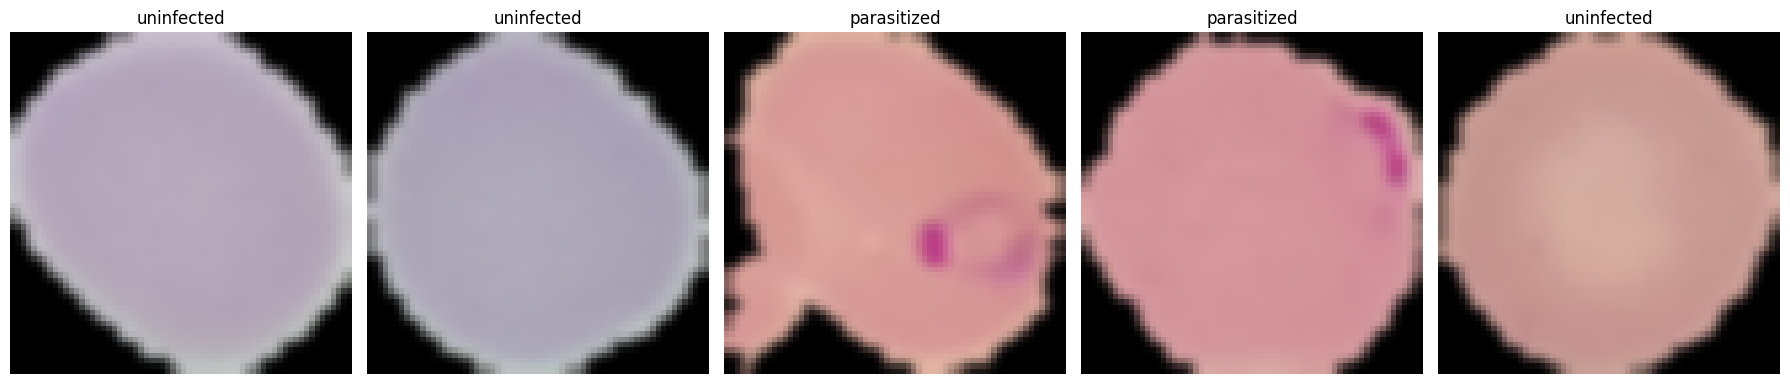

In [ ]:
# Get the class mapping from the generator for titles
class_labels_map = {v: k for k, v in train_generator.class_indices.items()}

viewimage = np.random.randint(0, len(gbx), 5) # Select random indices from the blurred images

fig, ax = plt.subplots(1, 5, figsize = (18, 18))

for t, i in zip(range(5), viewimage):
  # Use the original label (from the first 100 training labels) to get the class name
  original_label_index = np.arange(0, min(100, len(train_images)), 1)[i] # Get index within the first 100 images
  Title = class_labels_map[int(train_labels[original_label_index])]

  ax[t].set_title(Title)

  # Display the blurred image
  ax[t].imshow(gbx[i])

  ax[t].set_axis_off()

fig.tight_layout()

###<b> Gaussian Blurring on test data

In [ ]:
#apply gaussian blurring to test data
gbx_test = []  # To hold the blurred test images

#scale images to 0-255 and convert to uint8 for OpenCV, then apply gaussian blur
for i in range(len(test_images)):
  img_255 = (test_images[i] * 255).astype(np.uint8)
  b = cv2.GaussianBlur(img_255, (5, 5), 0)
  gbx_test.append(b)

gbx_test = np.array(gbx_test)

print(f"Shape of blurred test images: {gbx_test.shape}")

Shape of blurred test images: (6352, 64, 64, 3)


## **Model Building**

### **Base Model**




###<b> Importing the required libraries for building and training our Model

In [ ]:
import tensorflow as tf

from tensorflow.keras import backend

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from random import shuffle

backend.clear_session()

np.random.seed(42)

import random

random.seed(42)

tf.random.set_seed(42)

####<B>One Hot Encoding the train and test labels

In [ ]:
#encode train labels
print(f"Shape of train_labels before to_categorical: {train_labels.shape}")
if len(train_labels.shape) == 1 or train_labels.shape[1] != 2: # Only apply if not already one-hot encoded
    train_labels = to_categorical(train_labels, 2)
print(f"Shape of train_labels after to_categorical: {train_labels.shape}")

#encode test labels
print(f"Shape of test_labels before to_categorical: {test_labels.shape}")
if len(test_labels.shape) == 1 or test_labels.shape[1] != 2: # Only apply if not already one-hot encoded
    test_labels = to_categorical(test_labels, 2)
print(f"Shape of test_labels after to_categorical: {test_labels.shape}")

Shape of train_labels before to_categorical: (6400,)
Shape of train_labels after to_categorical: (6400, 2)
Shape of test_labels before to_categorical: (6352,)
Shape of test_labels after to_categorical: (6352, 2)


###<b> Building the model

In [ ]:
#create sequential model
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = 2, padding = "same", activation = "relu", input_shape = (64, 64, 3)))

model.add(MaxPooling2D(pool_size = 2))

model.add(Dropout(0.2))

model.add(Conv2D(filters = 32, kernel_size = 2, padding = "same", activation = "relu"))

model.add(MaxPooling2D(pool_size = 2))

model.add(Dropout(0.2))

model.add(Conv2D(filters = 32, kernel_size = 2, padding = "same", activation = "relu"))

model.add(MaxPooling2D(pool_size = 2))

model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(512, activation = "relu"))

model.add(Dropout(0.4))

model.add(Dense(2, activation = "softmax")) # 2 represents output layer neurons

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,058,786 (4.04 MB)

 Trainable params: 1,058,786 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

###<b> Compiling the model

In [ ]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

<b> Using Callbacks

In [ ]:
callbacks = [EarlyStopping(monitor = 'val_loss', patience = 2),
             ModelCheckpoint('best_model.keras', monitor = 'val_loss', save_best_only = True)]

<b> Fit and train our Model

In [ ]:
#fit model with min batch size as 32
history = model.fit(train_images, train_labels, batch_size = 32, callbacks = callbacks, validation_split = 0.2, epochs = 20, verbose = 1)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 30s 170ms/step - accuracy: 0.5659 - loss: 0.6838 - val_accuracy: 0.6570 - val_loss: 0.6382
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 38s 152ms/step - accuracy: 0.6683 - loss: 0.6215 - val_accuracy: 0.8516 - val_loss: 0.4928
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 40s 146ms/step - accuracy: 0.8532 - loss: 0.3950 - val_accuracy: 0.8906 - val_loss: 0.2079
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 155ms/step - accuracy: 0.9339 - loss: 0.1604 - val_accuracy: 0.9555 - val_loss: 0.1407
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 155ms/step - accuracy: 0.9581 - loss: 0.1184 - val_accuracy: 0.9586 - val_loss: 0.1408
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 41s 156ms/step - accuracy: 0.9651 - loss: 0.1116 - val_accuracy: 0.9727 - val_loss: 0.1208
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - accuracy: 0.9714 - loss: 0.0937 - val_accuracy: 0.9719 - val_loss: 0.0979
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 42s 152ms/step - accuracy: 0.9721 - loss: 0

###<b> Evaluating the model on test data

In [ ]:
accuracy = model.evaluate(test_images, test_labels, verbose = 1)
print('\n', 'Test_Accuracy:', accuracy[1])

199/199 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9721 - loss: 0.0990

 Test_Accuracy: 0.9738665223121643


<b> Plotting the confusion matrix

199/199 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      3752
           1       0.96      0.98      0.97      2600

    accuracy                           0.97      6352
   macro avg       0.97      0.97      0.97      6352
weighted avg       0.97      0.97      0.97      6352



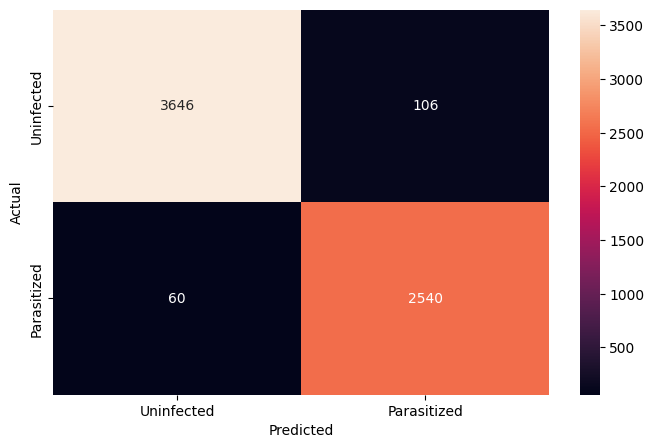

In [ ]:
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

pred = model.predict(test_images)

pred = np.argmax(pred, axis = 1)

y_true = np.argmax(test_labels, axis = 1)

#print the classification report
print(classification_report(y_true, pred))

#plot the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)

plt.figure(figsize = (8, 5))

sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ['Uninfected', 'Parasitized'], yticklabels = ['Uninfected', 'Parasitized'])

plt.ylabel('Actual')

plt.xlabel('Predicted')

plt.show()

<b>Plotting the train and validation curves

In [ ]:
#function to plot train and validation accuracy
def plot_accuracy(history):

    N = len(history.history["accuracy"])

    plt.figure(figsize = (7, 7))

    plt.plot(np.arange(0, N), history.history["accuracy"], label = "train_accuracy", ls = '--')

    plt.plot(np.arange(0, N), history.history["val_accuracy"], label = "val_accuracy", ls = '--')

    plt.title("Accuracy vs Epoch")

    plt.xlabel("Epochs")

    plt.ylabel("Accuracy")

    plt.legend(loc="upper left")

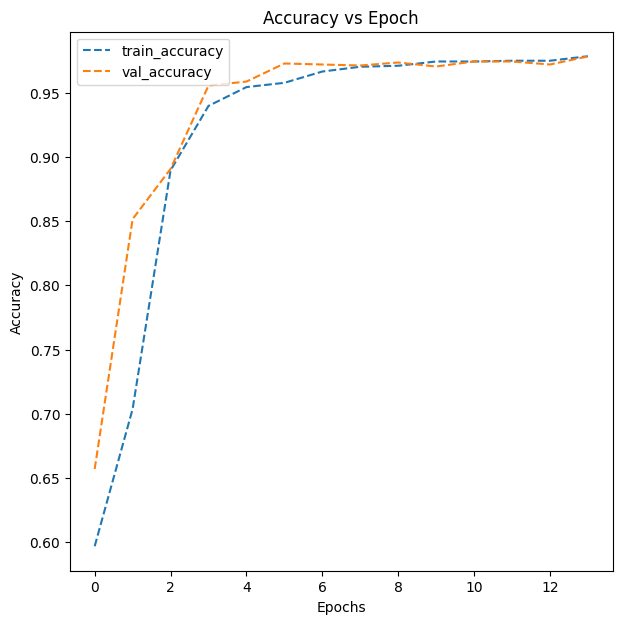

In [ ]:
plot_accuracy(history)

So now let's try to build another model with few more add on layers and try to check if we can try to improve the model. Therefore try to build a model by adding few layers if required and altering the activation functions.

###<b> Model 1
####<b> Trying to improve the performance of our model by adding new layers


In [ ]:
backend.clear_session() #clear

###<b> Building the Model

In [ ]:
#create sequential model
model1 = Sequential()

model1.add(Conv2D(filters = 64, kernel_size = 2, padding = "same", activation = "relu", input_shape = (64, 64, 3)))
model1.add(MaxPooling2D(pool_size = 2))
model1.add(Dropout(0.2))

model1.add(Conv2D(filters = 128, kernel_size = 2, padding = "same", activation = "relu"))
model1.add(MaxPooling2D(pool_size = 2))
model1.add(Dropout(0.3))

model1.add(Conv2D(filters = 256, kernel_size = 2, padding = "same", activation = "relu"))
model1.add(MaxPooling2D(pool_size = 2))
model1.add(Dropout(0.4))

model1.add(Flatten())

model1.add(Dense(1024, activation = "relu"))
model1.add(Dropout(0.5))

model1.add(Dense(2, activation = "softmax")) # 2 represents output layer neurons

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,945,346 (64.64 MB)

 Trainable params: 16,945,346 (64.64 MB)

 Non-trainable params: 0 (0.00 B)

###<b> Compiling the model

In [ ]:
model1.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

<b> Using Callbacks

In [ ]:
callbacks = [EarlyStopping(monitor = 'val_loss', patience = 2),
             ModelCheckpoint('best_model2.keras', monitor = 'val_loss', save_best_only = True)]

<b>Fit and Train the model

In [ ]:
history1 = model1.fit(train_images, train_labels, batch_size = 32, callbacks = callbacks,  validation_split = 0.2, epochs = 20, verbose = 1)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 155s 959ms/step - accuracy: 0.5550 - loss: 0.7346 - val_accuracy: 0.6812 - val_loss: 0.6075
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 187s 866ms/step - accuracy: 0.7650 - loss: 0.5231 - val_accuracy: 0.9156 - val_loss: 0.2428
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 140s 873ms/step - accuracy: 0.9325 - loss: 0.2072 - val_accuracy: 0.9508 - val_loss: 0.1513
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 143s 886ms/step - accuracy: 0.9488 - loss: 0.1411 - val_accuracy: 0.9625 - val_loss: 0.1214
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 154s 962ms/step - accuracy: 0.9662 - loss: 0.1110 - val_accuracy: 0.9734 - val_loss: 0.0901
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 192s 898ms/step - accuracy: 0.9769 - loss: 0.0865 - val_accuracy: 0.9688 - val_loss: 0.0931
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 149s 935ms/step - accuracy: 0.9759 - loss: 0.0749 - val_accuracy: 0.9719 - val_loss: 0.0884
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 154s 961ms/step - accuracy: 0.9793 -

###<b> Evaluating the model

In [ ]:
accuracy = model1.evaluate(test_images, test_labels, verbose = 1)
print('\n', 'Test_Accuracy:', accuracy[1])

199/199 ━━━━━━━━━━━━━━━━━━━━ 40s 201ms/step - accuracy: 0.9690 - loss: 0.1024

 Test_Accuracy: 0.9697732925415039


<b> Plotting the confusion matrix

199/199 ━━━━━━━━━━━━━━━━━━━━ 35s 175ms/step
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3752
           1       0.95      0.98      0.96      2600

    accuracy                           0.97      6352
   macro avg       0.97      0.97      0.97      6352
weighted avg       0.97      0.97      0.97      6352



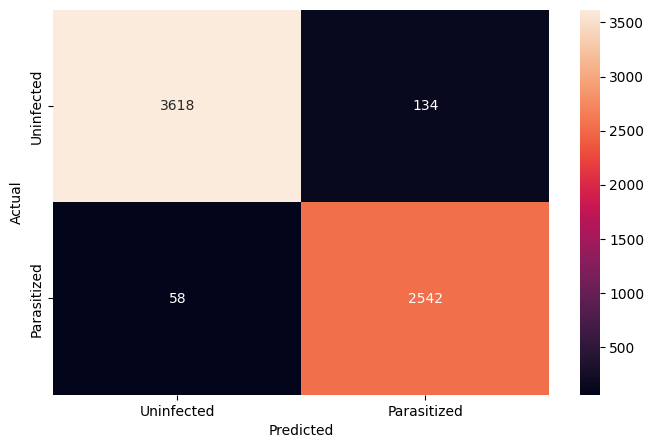

In [ ]:
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

pred = model1.predict(test_images)

pred = np.argmax(pred, axis = 1)

y_true = np.argmax(test_labels, axis = 1)

#print the classification report
print(classification_report(y_true, pred))

#plot the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)

plt.figure(figsize = (8, 5))

sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ['Uninfected', 'Parasitized'], yticklabels = ['Uninfected', 'Parasitized'])

plt.ylabel('Actual')

plt.xlabel('Predicted')

plt.show()

<b> Plotting the train and the validation curves

In [ ]:
#function to plot train and validation accuracy
def plot_accuracy(history):

    N = len(history.history["accuracy"])

    plt.figure(figsize = (7, 7))

    plt.plot(np.arange(0, N), history.history["accuracy"], label = "train_accuracy", ls = '--')

    plt.plot(np.arange(0, N), history.history["val_accuracy"], label = "val_accuracy", ls = '--')

    plt.title("Accuracy vs Epoch")

    plt.xlabel("Epochs")

    plt.ylabel("Accuracy")

    plt.legend(loc="upper left")

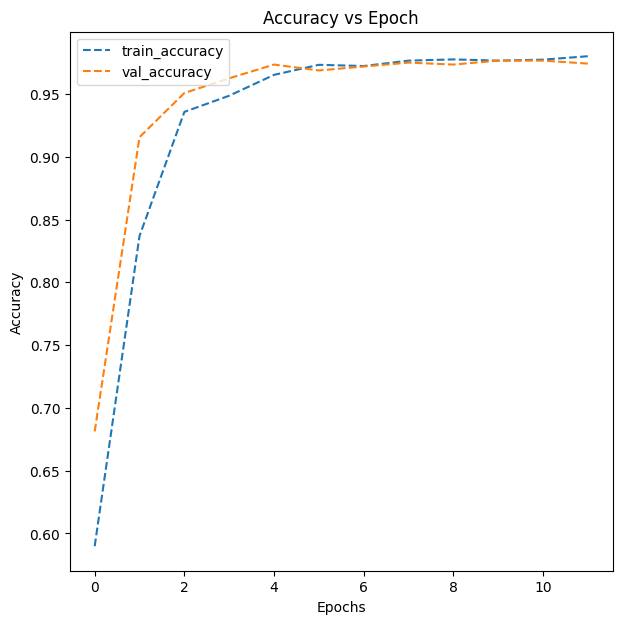

In [ ]:
plot_accuracy(history1)

###<b>Think about it:</b><br>
Now let's build a model with LeakyRelu as the activation function  

*  Can the model performance be improved if we change our activation function to LeakyRelu?

Potentially. We cannot determine whether model1 has a dying ReLU issue - where neurons can become inactive and stop learning if the input consistenly falls into the negative range. LeakyReLU would course correct this. We can attempt to see if the accuracy improves.

*  Can BatchNormalization improve our model?

Potentially, batch normalization can help stabalize neural networks during training.

Let us try to build a model using BatchNormalization and using LeakyRelu as our activation function.

###<b> Model 2 with Batch Normalization

In [ ]:
backend.clear_session() #clear

###<b> Building the Model

In [ ]:
#create sequential model
model2 = Sequential()

model2.add(Conv2D(filters = 32, kernel_size = 2, padding = "same", input_shape = (64, 64, 3)))
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.01))
model2.add(MaxPooling2D(pool_size = 2))
model2.add(Dropout(0.3))

model2.add(Conv2D(filters = 64, kernel_size = 2, padding = "same"))
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.01))
model2.add(MaxPooling2D(pool_size = 2))
model2.add(Dropout(0.2))

model2.add(Conv2D(filters = 128, kernel_size = 2, padding = "same"))
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.01))
model2.add(MaxPooling2D(pool_size = 2))
model2.add(Dropout(0.2))

model2.add(Flatten())

model2.add(Dense(512))
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.01))
model2.add(Dropout(0.3))

model2.add(Dense(2, activation = "softmax")) #2 represents output layer neurons

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,240,354 (16.18 MB)

 Trainable params: 4,238,882 (16.17 MB)

 Non-trainable params: 1,472 (5.75 KB)

###<b>Compiling the model

In [ ]:
model2.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

<b> Using callbacks

In [ ]:
callbacks = [EarlyStopping(monitor = 'val_loss', patience = 2),
             ModelCheckpoint('best_model2.keras', monitor = 'val_loss', save_best_only = True)]

<b>Fit and train the model

In [ ]:
history2 = model2.fit(train_images, train_labels, batch_size = 32, callbacks = callbacks, validation_split = 0.2, epochs = 20, verbose = 1)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 70s 412ms/step - accuracy: 0.6387 - loss: 0.7729 - val_accuracy: 0.5031 - val_loss: 0.8901
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 64s 400ms/step - accuracy: 0.8726 - loss: 0.3424 - val_accuracy: 0.5039 - val_loss: 1.8697
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 80s 390ms/step - accuracy: 0.9248 - loss: 0.2184 - val_accuracy: 0.5484 - val_loss: 1.5312


<b>Plotting the train and validation accuracy

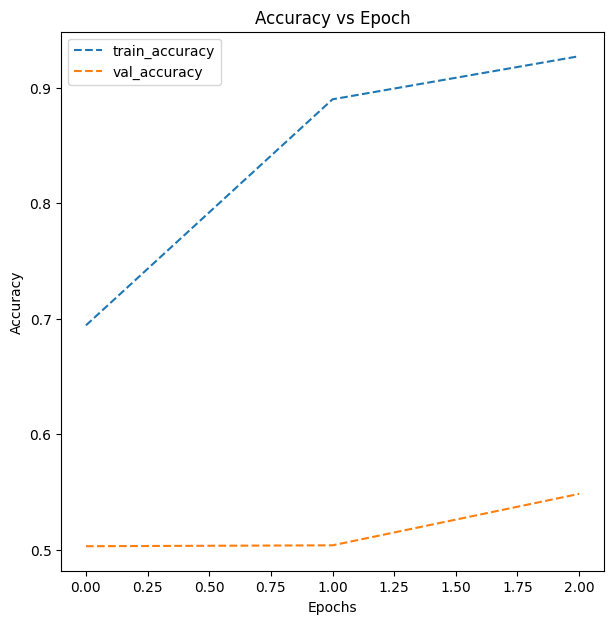

In [ ]:
plot_accuracy(history2)

###<b>Evaluating the model

In [ ]:
accuracy = model2.evaluate(test_images, test_labels, verbose = 1)
print('\n', 'Test_Accuracy:', accuracy[1])

199/199 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.3618 - loss: 2.1685

 Test_Accuracy: 0.4436397850513458


####<b>Observations and insights:



*   LeakyReLU can help with vanishing gradients, it appears the configuration or interaction with other layers might be causing instability during training, leading to the model failing to learn meaningful features.
*   The combination of LeakyReLU and Batch Normalization might have pushed the model into a state where it simply outputs the same prediction for everything.
*   Essentially, model 2 is not learning to differentiate between the two classes at all, consistently defaulting to one class. This is a severe form of underfitting or a complete failure in the learning process.



<b> Generate the classification report and confusion matrix

199/199 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step
              precision    recall  f1-score   support

           0       1.00      0.06      0.11      3752
           1       0.42      1.00      0.60      2600

    accuracy                           0.44      6352
   macro avg       0.71      0.53      0.35      6352
weighted avg       0.76      0.44      0.31      6352



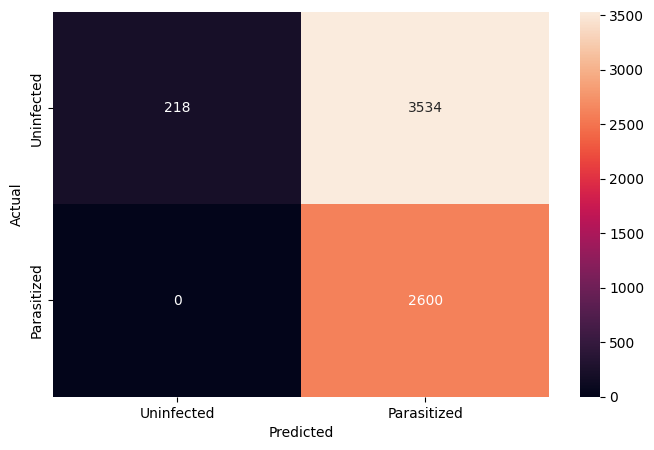

In [ ]:
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

pred = model2.predict(test_images)

pred = np.argmax(pred, axis = 1)

y_true = np.argmax(test_labels, axis = 1)

#print the classification report
print(classification_report(y_true, pred))

#plot the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)

plt.figure(figsize = (8, 5))

sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ['Uninfected', 'Parasitized'], yticklabels = ['Uninfected', 'Parasitized'])

plt.ylabel('Actual')

plt.xlabel('Predicted')

plt.show()

###**Think About It :**<br>

* Can we improve the model with Image Data Augmentation?

Image Data Augmentation could improve model performance, as it makes the model more robust to variation in the input data (which is something we can already see in the images of cells). Image Data Augmentation increases the size anddiveristy of the training dataset by creating modified versions of existing images, exposing the model to more general features whether than just memorizing specific examples of cells.

* References to image data augmentation can be seen below:
  *   [Image Augmentation for Computer Vision](https://www.mygreatlearning.com/blog/understanding-data-augmentation/)
  *   [How to Configure Image Data Augmentation in Keras?](https://machinelearningmastery.com/how-to-configure-image-data-augmentation-when-training-deep-learning-neural-networks/)





###<b>Model 3 with Data Augmentation

In [ ]:
backend.clear_session() #clear

###<b> Use image data generator

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(train_images, train_labels, test_size = 0.2, random_state = 42)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Using ImageDataGenerator to generate images
train_datagen = ImageDataGenerator(horizontal_flip = True,
                                  zoom_range = 0.5, rotation_range = 30)

val_datagen  = ImageDataGenerator()

# Flowing training images using train_datagen generator
train_generator = train_datagen.flow(x = X_train, y = y_train, batch_size = 64, seed = 42, shuffle = True)


# Flowing validation images using val_datagen generator
val_generator =  val_datagen.flow(x = X_val, y = y_val, batch_size = 64, seed = 42, shuffle = True)

###**Think About It :**<br>

*  Check if the performance of the model can be improved by changing different parameters in the ImageDataGenerator.



####<B>Visualizing Augmented images

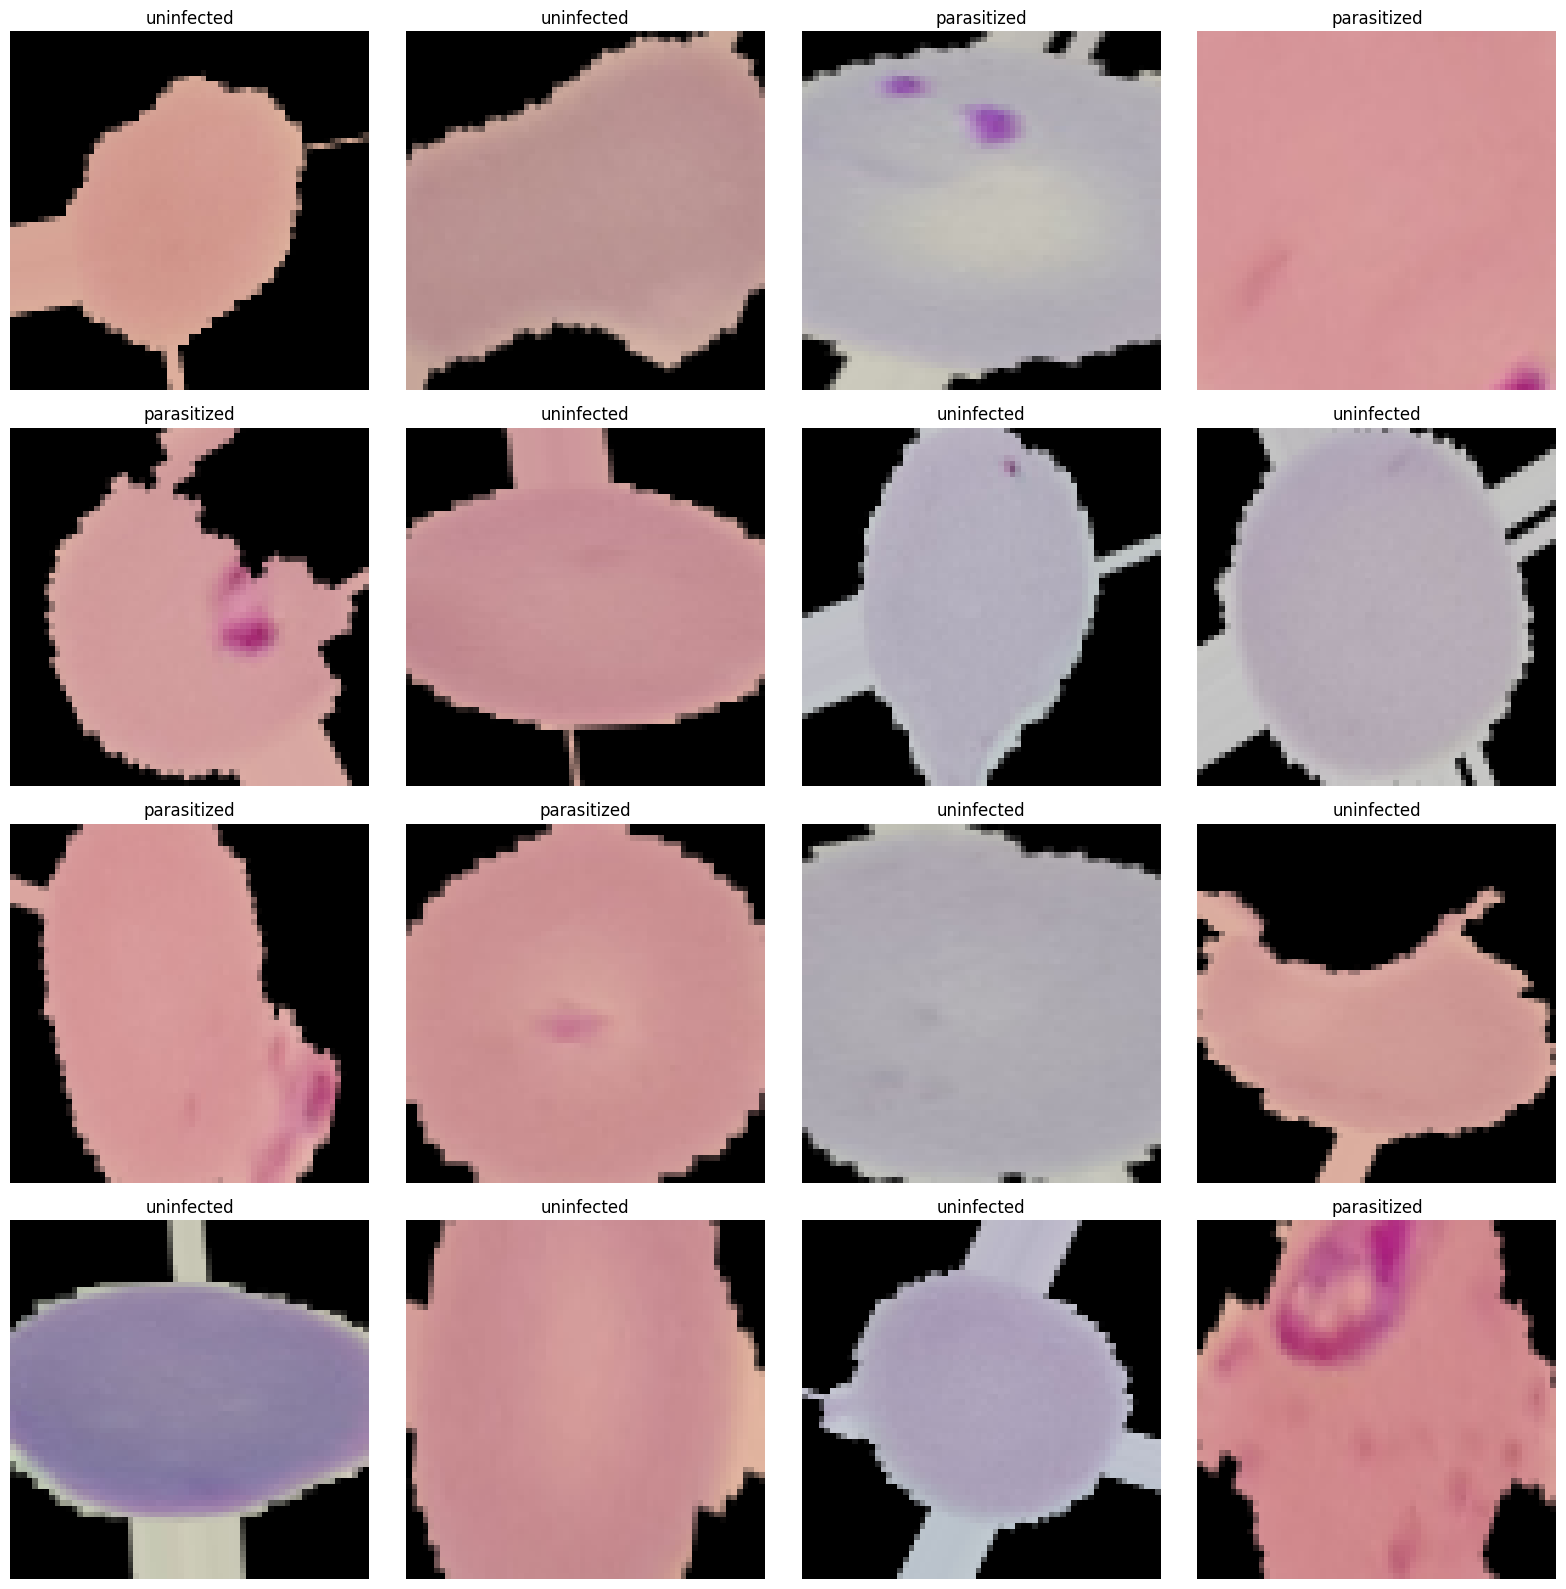

In [ ]:
#create iterable for images and labels from the training data
images, labels = next(train_generator)

#plot 16 images from the training data
fig, axes = plt.subplots(4, 4, figsize = (16, 8))

fig.set_size_inches(16, 16)
for (image, label, ax) in zip(images, labels, axes.flatten()):

    ax.imshow(image)

    #if label is [1, 0], it's parasitized. If label is [0, 1], it's uninfected.
    if label[0] == 1:
        ax.set_title('parasitized')
    else:
        ax.set_title('uninfected')

    ax.axis('off')
plt.tight_layout()
plt.show()

####<b>Observations and insights: ____

###<b>Building the Model

In [ ]:
from tensorflow.keras import optimizers

model3 = Sequential()

model3.add(Conv2D(filters = 32, kernel_size = 2, padding = "same", activation = "relu", input_shape = (64, 64, 3)))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(pool_size = 2))
model3.add(Dropout(0.1))

model3.add(Conv2D(filters = 64, kernel_size = 2, padding = "same", activation = "relu"))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(pool_size = 2))
model3.add(Dropout(0.2))

model3.add(Conv2D(filters = 128, kernel_size = 2, padding = "same", activation = "relu"))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(pool_size = 2))
model3.add(Dropout(0.2))

model3.add(Flatten())

model3.add(Dense(512, activation = "relu"))
model3.add(BatchNormalization())
model3.add(Dropout(0.3))

model3.add(Dense(2, activation = "softmax")) #2 represents output layer neurons

# Use this as the optimizer
adam = optimizers.Adam(learning_rate = 0.001)

model3.compile(loss = 'binary_crossentropy', optimizer = adam, metrics = ['accuracy'])

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,240,354 (16.18 MB)

 Trainable params: 4,238,882 (16.17 MB)

 Non-trainable params: 1,472 (5.75 KB)

<b>Using Callbacks

In [ ]:
callbacks = [EarlyStopping(monitor = 'val_loss', patience = 2),
             ModelCheckpoint('best_model4.keras', monitor = 'val_loss', save_best_only = True)]

<b> Fit and Train the model

In [ ]:
history3 = model3.fit(train_generator,
                                  validation_data = val_generator,
                                  batch_size = 64, callbacks = callbacks,
                                  epochs = 20, verbose = 1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 79s 927ms/step - accuracy: 0.6049 - loss: 0.9195 - val_accuracy: 0.4727 - val_loss: 1.0512
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 74s 924ms/step - accuracy: 0.7497 - loss: 0.5475 - val_accuracy: 0.4742 - val_loss: 2.2287
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 73s 916ms/step - accuracy: 0.8556 - loss: 0.3676 - val_accuracy: 0.4727 - val_loss: 5.0897


###<B>Evaluating the model

<b>Plot the train and validation accuracy

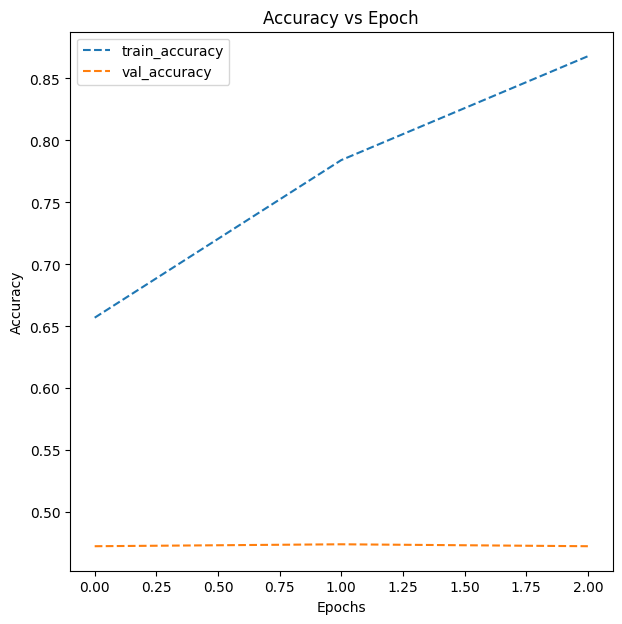

In [ ]:
# Potting the accuracies
plot_accuracy(history3)

<B>Plotting the classification report and confusion matrix

In [ ]:
# Evaluating the model on test data
accuracy3 = model3.evaluate(test_images, test_labels, verbose = 1)

print('\n', 'Test_Accuracy:-', accuracy3[1])

199/199 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.3263 - loss: 6.5317

 Test_Accuracy:- 0.4093199074268341


<b> Now, let us try to use a pretrained model like VGG16 and check how it performs on our data.

### **Pre-trained model (VGG16)**
- Import VGG16 network upto any layer you choose
- Add Fully Connected Layers on top of it

In [ ]:
# Clearing backend
from tensorflow.keras import backend

backend.clear_session()

# Fixing the seed for random number generators
np.random.seed(42)

import random

random.seed(42)

tf.random.set_seed(42)

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16

from tensorflow.keras import Model

vgg = VGG16(include_top = False, weights = 'imagenet', input_shape = (64, 64, 3))

vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
transfer_layer = vgg.get_layer('block5_pool')

vgg.trainable = False

# Add classification layers on top of it
x = Flatten()(transfer_layer.output)  # Flatten the output from the 3rd block of the VGG16 model

x = Dense(256, activation = 'relu')(x)

# Similarly add a dense layer with 128 neurons
x = Dropout(0.3)(x)

# Add a dense layer with 64 neurons
x = BatchNormalization()(x)

pred = Dense(2, activation = 'softmax')(x)

model4 = Model(vgg.input, pred) # Initializing the model

###<b>Compiling the model

In [ ]:
model4.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

<b> using callbacks

In [ ]:
callbacks = [EarlyStopping(monitor = 'val_loss', patience = 2),
             ModelCheckpoint('best_model_vgg16.keras', monitor = 'val_loss', save_best_only = True)]

<b>Fit and Train the model

In [ ]:
# Fitting the model and running the model for 10 epochs
history4 = model4.fit(
            train_images, train_labels,
            epochs = 10,
            callbacks = callbacks,
            batch_size = 32,
            validation_split = 0.2,
            verbose = 1
)

Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.9430 - loss: 0.1572 - val_accuracy: 0.9320 - val_loss: 0.1884
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 400s 3s/step - accuracy: 0.9431 - loss: 0.1586 - val_accuracy: 0.9289 - val_loss: 0.1891
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.9470 - loss: 0.1459 - val_accuracy: 0.9164 - val_loss: 0.1858
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.9501 - loss: 0.1369 - val_accuracy: 0.9266 - val_loss: 0.1915
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.9461 - loss: 0.1433 - val_accuracy: 0.9148 - val_loss: 0.2162


<b>Plot the train and validation accuracy

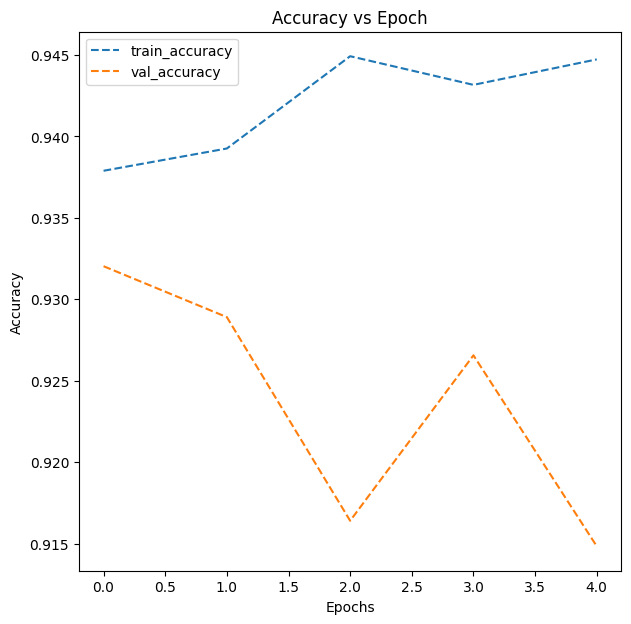

In [ ]:
# plotting the accuracies
plot_accuracy(history4)

###**Observations and insights: **

*   What can be observed from the validation and train curves?
This pattern is an indication that the model is beginning to overfit to the training data. While it continues to improve its performance on the training set, its ability to generalize to new, unseen data starts to diminish after roughly 4-5 epochs.

###<b> Evaluating the model

In [ ]:
accuracy4 = model4.evaluate(test_images, test_labels, verbose = 1)
print('\n', 'Test_Accuracy:', accuracy4[1])

199/199 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.9212 - loss: 0.1793

 Test_Accuracy: 0.9124684929847717


<b>Plotting the classification report and confusion matrix

199/199 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3752
           1       0.95      0.83      0.89      2600

    accuracy                           0.91      6352
   macro avg       0.92      0.90      0.91      6352
weighted avg       0.92      0.91      0.91      6352



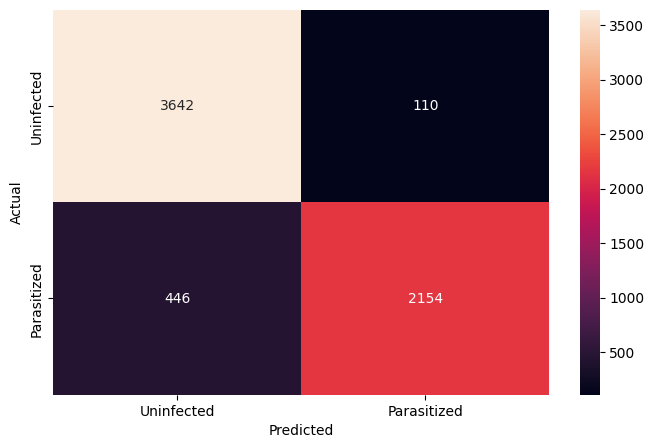

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

pred = model4.predict(test_images)

pred = np.argmax(pred, axis = 1)

y_true = np.argmax(test_labels, axis = 1)

#print the classification report
print(classification_report(y_true, pred))

#plot the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)

plt.figure(figsize = (8, 5))

sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ['Uninfected', 'Parasitized'], yticklabels = ['Uninfected', 'Parasitized'])

plt.ylabel('Actual')

plt.xlabel('Predicted')

plt.show()

###<b>Think about it:</b>
*  What observations and insights can be drawn from the confusion matrix and classification report?

The model demonstrated a high recall for the 'parasitized' class (0.97), meaning it was good at identifying most positive cases. However, its precision for this class was slightly lower (0.89), suggesting it also made some false positive predictions (labeled uninfected cells as parasitized).
Conversely, for the 'uninfected' class, it had high precision (0.95), indicating that when it predicted a cell was uninfected, it was usually correct. But its recall was lower (0.83), meaning it missed some truly uninfected cells (labeled them as parasitized).

In sum, model 4, showed promise but suffered from overfitting given the dataset size and the frozen nature of its base layers. However, it performed better than model2 and model3, but not as well as the Base Model.

####<b> Observations and Conclusions drawn from the final model:



**Improvements that can be done:**<br>


*  Can the model performance be improved using other pre-trained models or different CNN architecture?
*  You can try to build a model using these HSV images and compare them with your other models.

The model performance can be improved by exploring and adjusting the following:

1. Hyperparameter Tuning (for Base Model): Systematically tune learning rate, batch size, dropout rates, and optimizer parameters for the Base Model.
2. Revisit Batch Normalization and LeakyReLU: Instead of a full architectural change like we had done in Model 2, we should instead carefully reintroduce Batch Normalization and LeakyReLU to the Base Model, but with much lower dropout rates (0.1, 0.2) and thorough tuning of alpha (0.005 or 0.05) and learning rate.
3. Optimized Data Augmentation: Apply fine-tuned data augmentation parameters to the Base Model to make it more robust. (The catastrophic failure of Model 3 suggests something beyond just augmentation was wrong with its underlying architecture/hyperparameters).
4. HSV Image Models: We could train models on HSV-converted images, as HSV highlighted the ring-like strucutres that are found in parasitic cells, making it easier to distinguish a cell that is infected versus not. Therefore, HSV-converted images would allow the model to learn much quicker and perhaps improve accuracy scores. An interesting test would be to combine Gaussian Blurring with HSV-converted images for further fine-tuning and focus.
5. Other Pre-trained Models / Fine-tuning VGG16: Explore other pre-trained architectures (ResNet, EfficientNet) or extensively fine-tune VGG16 by unfreezing some convolutional layers and applying careful learning rate scheduling and regularization. The early overfitting of VGG16 indicates that even for pre-trained models, the added dense layers need proper regularization.


#### **Insights**

####**Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

1. Key Distinguisher: The primary visual cue for malaria infection is the presence of 'ring-like structures' within red blood cells. These structures are darker and appear in various locations within infected cells.

2. Image Pre-processing: Resizing images to 64x64 pixels and normalizing pixel values (0-1 range) were essential pre-processing steps for efficient model training and stable learning.

3. Class Balance: The dataset showed good balance, with approximately equal numbers of parasitized and uninfected cells in both training and test sets after data generation, which is crucial for fair model evaluation and avoiding bias.

4. HSV Conversion for Feature Enhancement: Converting RGB images to HSV can significantly highlight the parasitic structures, making them more visually distinct. This suggests potential benefits for models trained on HSV-transformed images.

####**Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

Base Model (Sequential CNN):

1. Simple CNN with 3 Conv2D layers, MaxPooling, and Dropout, followed by Dense layers.
Test Accuracy: ~97.39%
Observations: Achieved strong performance quickly, showing that a simple CNN can learn from pre-processed image data. The training and validation accuracy curves showed good convergence with minimal overfitting initially.

Model 1 (Increased Capacity CNN):

2. Similar to the base model but with increased filters (64, 128, 256) and higher dropout rates, no Batch Normalization.
Test Accuracy: ~96.98%
Observations: Performance was slightly lower than the Base Model. This suggests that simply increasing model capacity and dropout without other stabilizing techniques (like Batch Normalization) might not always lead to improvements, or that it might have led to earlier overfitting with the given data size.

Model 2 (Batch Normalization + LeakyReLU CNN):

3. Added Batch Normalization and LeakyReLU activations into the CNN layers.
Test Accuracy: ~44.36% (Catastrophic Failure)
Observations: This model performed extremely poorly. It essentially collapsed, consistently predicting only one class ('uninfected') for nearly all samples. This highlights that while Batch Normalization and LeakyReLU are powerful techniques, their combination or specific hyperparameter settings (high dropout rates with BN) can lead to unstable training and complete learning failure if not carefully tuned.

Model 3 (Data Augmentation + BN CNN):

4. CNN with Batch Normalization and ReLU activations, trained with data augmentation.
Test Accuracy: ~40.93% (Catastrophic Failure)
Observations: Similar to Model 2, this model also experienced a catastrophic failure, performing worse than random chance. This indicates that despite data augmentation, there were still underlying issues with the model's architecture or the combination of its layers that prevented it from learning effectively.

Pre-trained Model (VGG16):

5. Used the VGG16 base (frozen layers) with added custom dense classification layers.
Test Accuracy: ~91.25%
Observations: Pre-trained models typically offer a strong starting point, and VGG16 showed good initial validation accuracy. The observed overfitting highlights the need for fine-tuning, appropriate regularization, and possibly more careful selection of frozen layers or adding more regularization for the new dense layers.

####**Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?

The Base Model has the Highest Proven Accuracy: The Base Model achieved the highest test accuracy (97.39%) among the models that successfully completed evaluation, demonstrating strong predictive power on unseen data.
Simplicity and Stability: Its relatively simpler architecture proved more stable and robust in learning compared to the more complex (Model 2, Model 3) or pre-trained (VGG16) models without extensive hyperparameter tuning.
Good Generalization: The balanced performance on both training and validation sets (before the early stopping) indicates good generalization ability for the task.